Imports & paths

In [4]:
# Translate MATLAB → Python (ND2 → spectral processing)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import mode
from nd2 import ND2File

# ---- Choose  file ----
# For Nile Red on PS
yi = np.array([219, 233, 249, 269])  # detector pixel positions (Y) for known lines
x0 = 92

# # For Nile Red on Glass
# yi = np.array([208, 223, 239, 258])
# x0 = 81

# Set your ND2 path (copy the one you used in MATLAB)
# For Nile Red on PS
nd2_path = r"D:\HongjingMao\SpecUnet\NileRed\8.21Nile Red on PS\No binning cali005.nd2"

# # For Nile Red on Glass
# nd2_path = r"D:\HongjingMao\Manuscript\NileRed\8.07 Nile Red on glass\Channel561_narrow003.nd2"


Calibration (polyfit → fx, fx2, fx3)

In [5]:
# %%
# Calibration Information
xi = np.array([436.6, 487.7, 546.5, 611.6])  # known wavelengths (nm)
fy  = np.arange(500, 801, 3)   # OG 550:3:800
fy2 = np.arange(500, 801, 1)   # OG 550:1:800
fy3 = np.arange(500, 801, 3)   # for photon calc

# Linear fit: pixel (Y) vs wavelength
coeffs = np.polyfit(xi, yi, 1)
fx  = np.polyval(coeffs, fy)
fx2 = np.polyval(coeffs, fy2)
fx3 = np.polyval(coeffs, fy3)


Load ND2 (bfopen equivalent) → A (H×W×T)

In [6]:
# %%
print(f"Opening ND2: {nd2_path}")
with ND2File(nd2_path) as nd2f:
    sizes = nd2f.sizes
    T = sizes.get('T', 1)
    H = sizes['Y']
    W = sizes['X']

    A = np.zeros((H, W, T), dtype=np.float32)
    for i in range(T):
        A[:, :, i] = nd2f.read_frame(i)

A9 = A.copy()

print("Loaded A with shape:", A.shape, "dtype:", A.dtype)


Opening ND2: D:\HongjingMao\SpecUnet\NileRed\8.21Nile Red on PS\No binning cali005.nd2
Loaded A with shape: (200, 400, 3000) dtype: float32


Average image, slit position (mode of rowwise maxima within first 100 px)

Estimated slit (1-based column index): 65


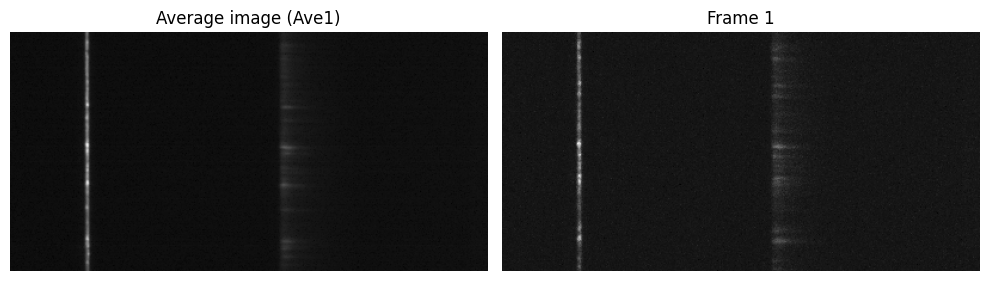

In [7]:
# Average across time
Ave1 = A9.mean(axis=2)

# For each row, find x position (within first 100 columns) of max intensity
slit_position = np.argmax(Ave1[:, :100], axis=1) + 1  # +1 to mimic MATLAB's 1-based intermediate
# Mode → most common slit column (still 1-based here)
slit_value, _ = mode(slit_position, keepdims=False)
slit = int(slit_value)  # 1-based

print("Estimated slit (1-based column index):", slit)

# Quick visualization
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(Ave1, cmap='gray')
axs[0].set_title("Average image (Ave1)")
axs[0].axis('off')

axs[1].imshow(A[:, :, 0], cmap='gray')
axs[1].set_title("Frame 1")
axs[1].axis('off')
plt.tight_layout()
plt.show()


Global background (per row using “good” frames)

In [8]:
# back(n,:) = mean over frames with low mean( A[n, 150:350, :] ), threshold 109
back = np.zeros((A.shape[0], A.shape[1]), dtype=np.float32)

col_lo, col_hi = 150, 350  # inclusive in MATLAB; Python slices end exclusive, so use 150:351
roi = A[:, col_lo:351, :]  # shape: H × (col_hi-col_lo+1) × T
w = roi.mean(axis=1)       # per row, per frame (H × T)
a = w < 109                # boolean mask of "dark" frames per row
for n in range(A.shape[0]):  # for each row
    good_frames = a[n, :]
    if not np.any(good_frames):
        # fallback: if none are below threshold, use all frames
        good_frames = np.ones(A.shape[2], dtype=bool)
    back[n, :] = A[n, :, good_frames].mean(axis=2)

plt.figure(figsize=(6,4))
plt.imshow(back, cmap='gray')
plt.title("Estimated background (per row)")
plt.axis('off')
plt.show()


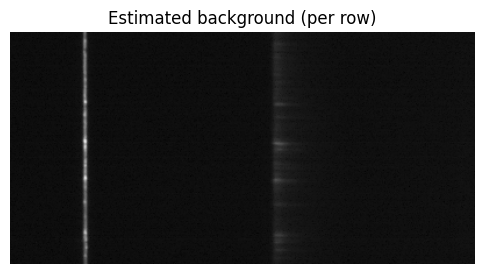

In [10]:
# %%  --- FIXED: Global background (per row using “dark” frames) ---
back = np.zeros((A.shape[0], A.shape[1]), dtype=np.float32)

col_lo, col_hi = 150, 350  # MATLAB was 150:350 inclusive
roi = A[:, col_lo:351, :]  # 351 because Python's stop is exclusive
w = roi.mean(axis=1)       # shape: (H, T)
a = w < 109                # "dark" frames mask, shape (H, T)

for n in range(A.shape[0]):  # each row
    good_frames = a[n, :]
    if not np.any(good_frames):
        good_frames = np.ones(A.shape[2], dtype=bool)
    # A[n, :, good_frames] -> shape (num_good_frames, W) because boolean indexing is advanced
    # Average across frames (axis=0) to get a (W,) row
    back[n, :] = A[n, :, good_frames].mean(axis=0)

plt.figure(figsize=(6,4))
plt.imshow(back, cmap='gray')
plt.title("Estimated background (per row)")
plt.axis('off')
plt.show()



Background subtraction; keep A1 for “ML”

In [11]:
# Expand background to full stack
back_stack = np.repeat(back[:, :, None], A.shape[2], axis=2)

# For processing (Shahid method)
A_proc = A - back_stack

# For ML
A1 = A_proc + back_stack  # equals original A; kept to mirror MATLAB variable naming


Peak detection along summed slit band (per frame)

In [17]:
TR_list = []  # collect [y, x, n] (1-based)

t = 500  # For Glass you noted t=500; you can adjust if needed
slit0 = slit - 1  # 0-based

for n in range(A_proc.shape[2]):  # frame index (0-based)
    c0 = max(0, slit0 - 3)
    c1 = min(A_proc.shape[1] - 1, slit0 + 3)
    band = A_proc[:, c0:c1+1, n]     # H × 7
    srow = band.sum(axis=1)          # length H

    peaks, _ = find_peaks(srow, height=t, distance=3)
    if peaks.size > 0:
        for y_idx in peaks:          # 0-based
            if 3 < (y_idx + 1) < 196:   # MATLAB: y<196 & y>3 (1-based)
                r0 = max(0, y_idx - 2)
                r1 = min(A_proc.shape[0] - 1, y_idx + 2)
                cmax = min(A_proc.shape[1] - 1, slit0 + 10)
                b2 = A_proc[r0:r1+1, 0:cmax+1, n]   # rows × cols
                s_x = b2.sum(axis=0)
                x_idx = int(np.argmax(s_x))         # 0-based
                TR_list.append([y_idx + 1, x_idx + 1, n + 1])  # 1-based like MATLAB

# Always 2-D shape (N,3); empty → (0,3); single → (1,3)
TR = np.array(TR_list, dtype=int).reshape(-1, 3)
print(f"Found peaks: {TR.shape[0]}")


Found peaks: 42


Spectra crops (bb, bbshort, bbimg) + slice filtering

In [38]:
# s = [x, y, n] (1-based)
if TR.shape[0] == 0:
    print("No peaks found. Consider lowering t (e.g., 500) or verifying slit detection.")
    # Optional quick diagnostic:
    # plt.figure(); plt.plot(A_proc[:, max(0, slit-1-3):slit-1+4, 0].sum(axis=1)); plt.title("Summed profile (frame 1)"); plt.show()
else:
    s = TR[:, [1, 0, 2]]  # proceed as before

s = TR[:, [1, 0, 2]]

y0_shift = 0
bb3 = []
bb3short = []

# bs rows will be interpolated later; collect in list then stack
bs_list = []

# Preallocate bbimg: (17 × 86 × N); we’ll build dynamically then filter
bbimg_list = []
keep_slice = []

# Helper to clamp indices to valid range
def clamp(v, lo, hi):
    return int(max(lo, min(hi, v)))

H, W, T = A.shape

for idx in range(s.shape[0]):
    x_1b, y_1b, n_1b = s[idx]
    n0 = n_1b - 1  # 0-based frame

    # Columns corresponding to fx range, shifted by -x0 + s(n,1)
    cols_fx  = np.round(fx).astype(int)
    cols_fx3 = np.round(fx3).astype(int)

    # Convert to 0-based columns inside image:
    cols  = cols_fx  - x0 + x_1b
    cols3 = cols_fx3 - x0 + x_1b

    # Rows for bb/bbshort: (-1:1)+y + y0_shift  (3 rows)
    rows_small = (np.arange(-1, 2) + (y_1b + y0_shift)).astype(int)

    # bb (3 × len(fx))
    rows_small_c = np.clip(rows_small - 1, 0, H-1)
    cols_c       = np.clip(cols - 1, 0, W-1)
    bb = A[rows_small_c[:,None], cols_c[None,:], n0]
    bb2 = bb.sum(axis=0)
    bb3.append(bb2.sum())

    # bbshort (3 × len(fx3)) for photons (600–800nm in your OG comment;
    # here use defined fy3 value)
    cols3_c = np.clip(cols3 - 1, 0, W-1)
    bbshort = A[rows_small_c[:,None], cols3_c[None,:], n0]
    bb2short = bbshort.sum(axis=0)
    bb3short.append(bb2short.sum())

    # bbimg subimage (17 rows × 86 cols) from A1
    # (-11:5) + y for Glass  (comment in MATLAB)
    # row_indices = (np.arange(-11, 6) + (y_1b + y0_shift)).astype(int)  # 17 rows
    row_indices = (np.arange(-5, 12) + (y_1b + y0_shift)).astype(int)  # 17 rows
    col_indices = cols  # same spectral columns as bb

    row_indices_c = np.clip(row_indices - 1, 0, H-1)
    col_indices_c = np.clip(col_indices - 1, 0, W-1)

    bbimg_slice = A1[row_indices_c[:,None], col_indices_c[None,:], n0]  # 17×len(fx)
    bbimg_list.append(bbimg_slice)

    # Discard slices with “flat” top/bottom (first 3 rows identical OR last 3 identical)
    first3 = bbimg_slice[0:3, :]
    last3  = bbimg_slice[-3:, :]

    def rows_identical(block):
        # true if all rows identical
        return np.unique(block, axis=0).shape[0] == 1

    keep = not (rows_identical(first3) or rows_identical(last3))
    keep_slice.append(keep)

    # bs(n,:) = interp1(round(fx(1)):round(fx(end)), bb2, fx2)
    x_src = np.arange(np.round(fx[0]), np.round(fx[-1]) + 1)  # integer support
    # bb2 was summed over rows_small; we need it sampled on x_src
    # Ensure bb2 aligns to that support:
    # Our bb2 currently corresponds to integer-rounded fx entries;
    # create an array of length = len(x_src) filled with 0, then scatter-add
    bs_src = np.zeros(x_src.size, dtype=bb2.dtype)
    # Map cols (rounded fx) to indices within x_src
    x0_src = int(x_src[0])
    idxs = (cols - x0_src).astype(int)
    ok = (idxs >= 0) & (idxs < bs_src.size)
    bs_src[idxs[ok]] = bb2[ok]

    # Interpolate onto fx2 (integer nm)
    from numpy import interp
    bs_interp = interp(fx2, x_src, bs_src)  # linear
    bs_list.append(bs_interp)

bb3      = np.array(bb3, dtype=float)
bb3short = np.array(bb3short, dtype=float)
bbimg    = np.stack(bbimg_list, axis=2)  # 17 × len(fx) × N
keep_slice = np.array(keep_slice, dtype=bool)

# Filter bbimg (keep only slices marked True)
bbimg = bbimg[:, :, keep_slice]
bs = np.stack(bs_list, axis=0) if len(bs_list) else np.zeros((0, fx2.size))

print("bbimg shape (rows × cols × kept):", bbimg.shape)
print("bs shape (N × len(fx2)):", bs.shape)


bbimg shape (rows × cols × kept): (17, 101, 42)
bs shape (N × len(fx2)): (42, 301)


“ML” resize: crop to 16×128 per slice (linear interp across columns)

In [39]:
# cropped_bbimg = bbimg(1:end-1, :, :)  -> drop last row to make 16
cropped_bbimg = bbimg[0:-1, :, :]  # 16 × C × N
rows_16, C, N = cropped_bbimg.shape

final_cols = 128
orig_cols = np.linspace(1, C, C)
new_cols  = np.linspace(1, C, final_cols)

final_bbimg = np.zeros((rows_16, final_cols, N), dtype=cropped_bbimg.dtype)

for k in range(N):
    for j in range(rows_16):
        final_bbimg[j, :, k] = np.interp(new_cols, orig_cols, cropped_bbimg[j, :, k])

# Filtering / photon budget vars (mirroring MATLAB names)
bs3 = bs.copy()
bs3[np.isnan(bs3)] = 0
s_photons = bb3short * 1.1 / 0.95  # OG scaling from MATLAB
print("final_bbimg:", final_bbimg.shape, "| s_photons:", s_photons.shape)


final_bbimg: (16, 128, 42) | s_photons: (42,)


Preview a few frames (grayscale like MATLAB)

<Figure size 640x480 with 0 Axes>

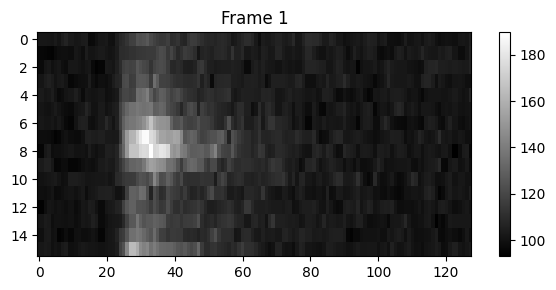

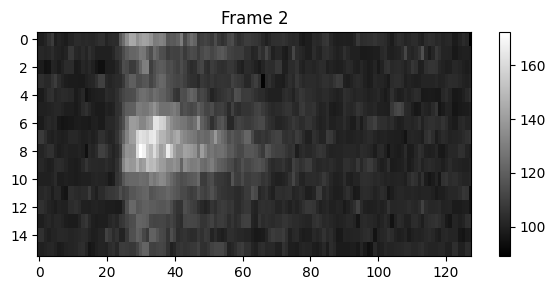

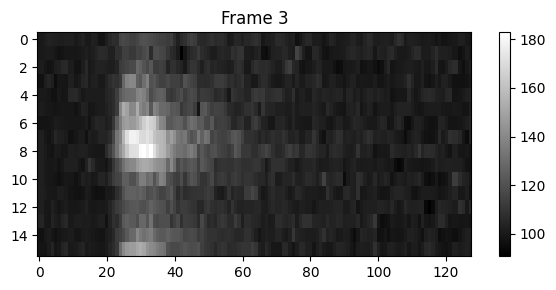

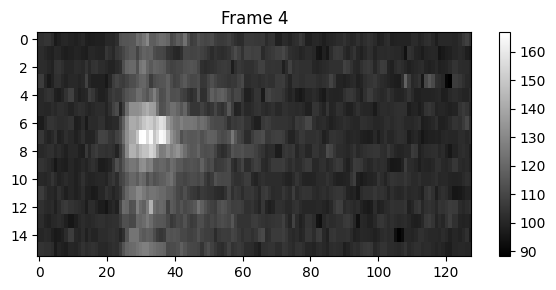

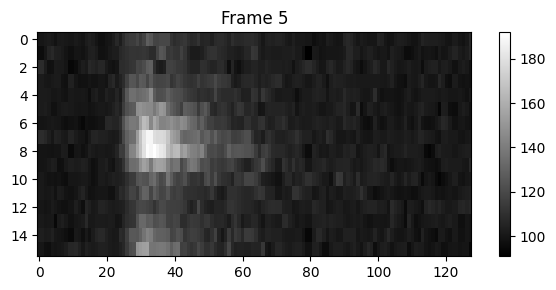

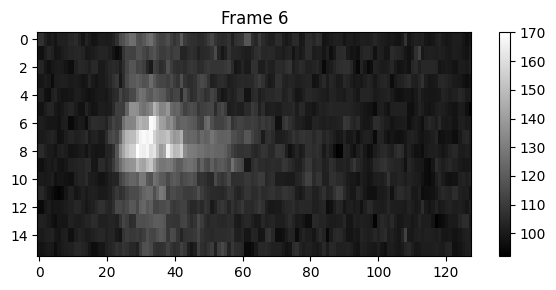

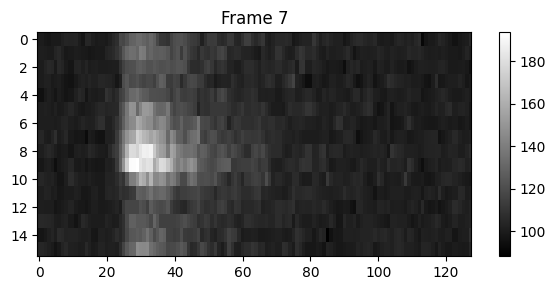

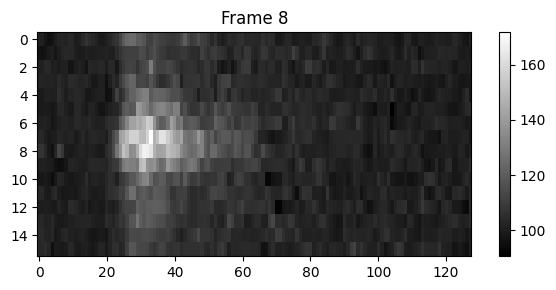

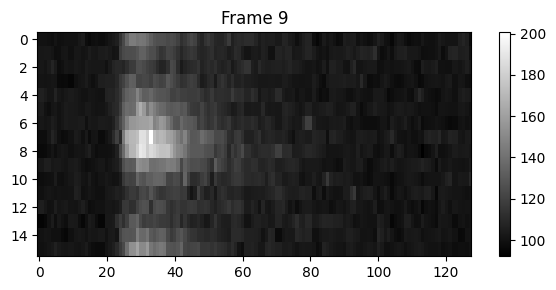

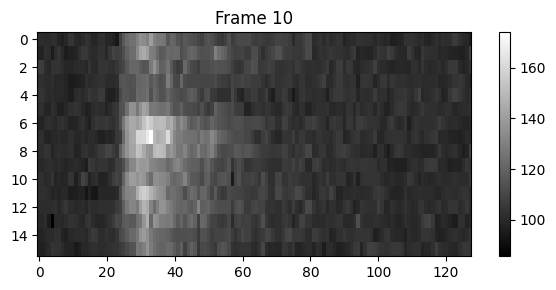

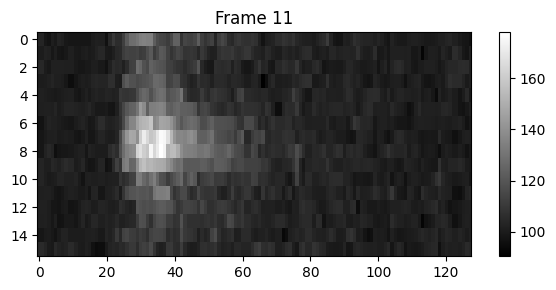

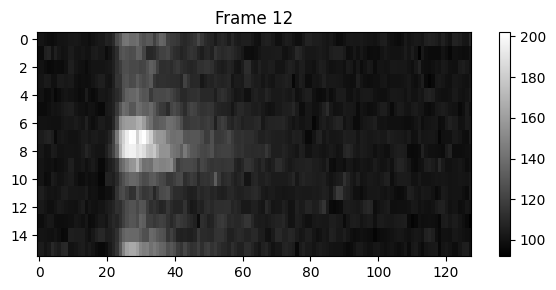

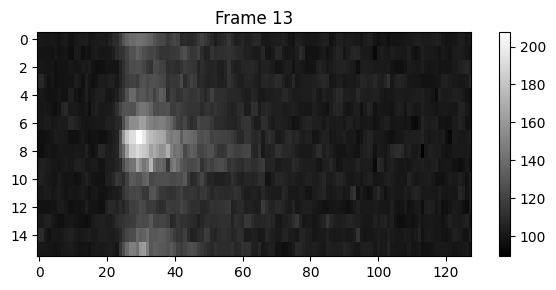

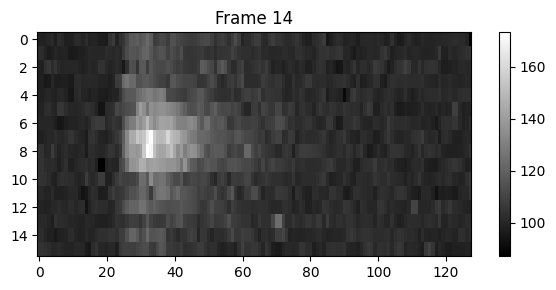

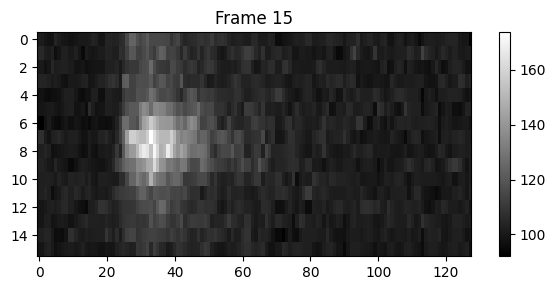

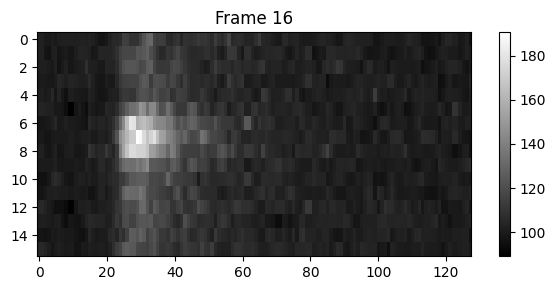

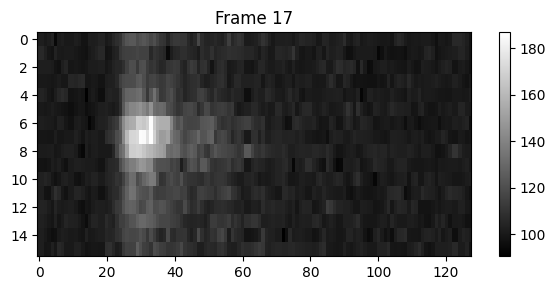

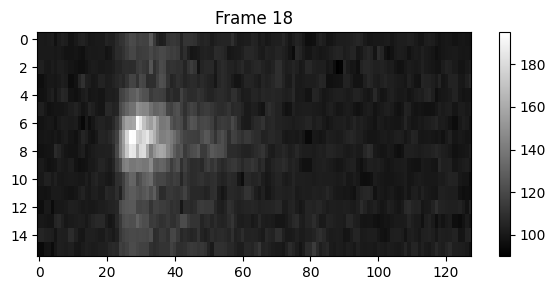

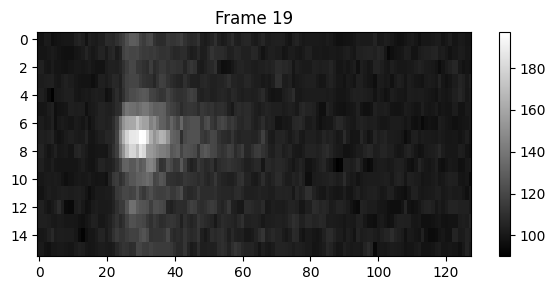

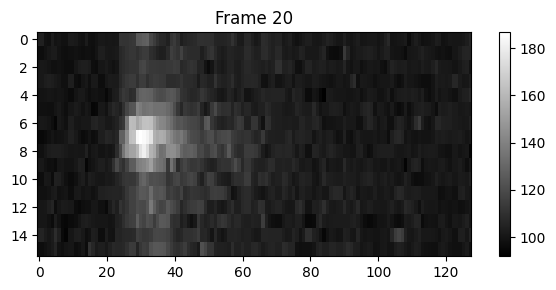

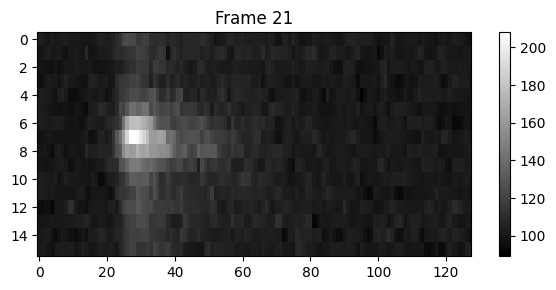

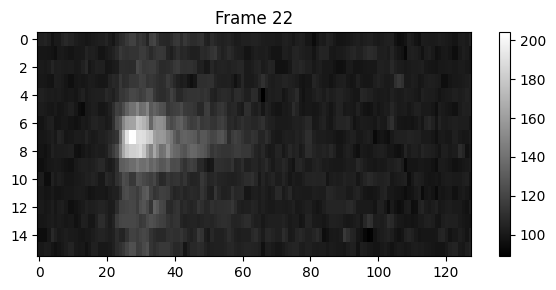

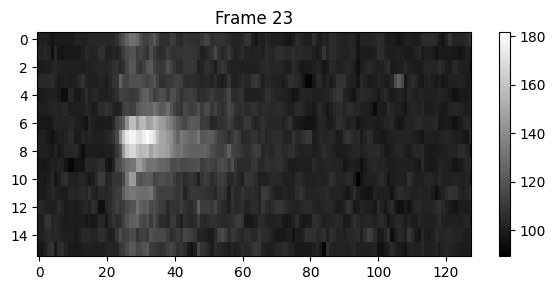

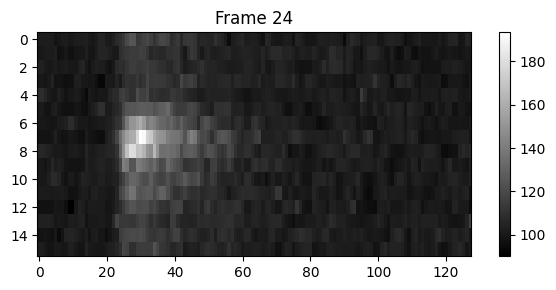

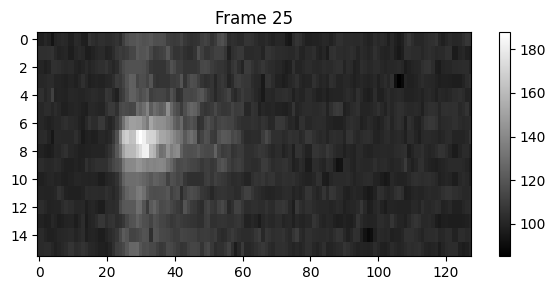

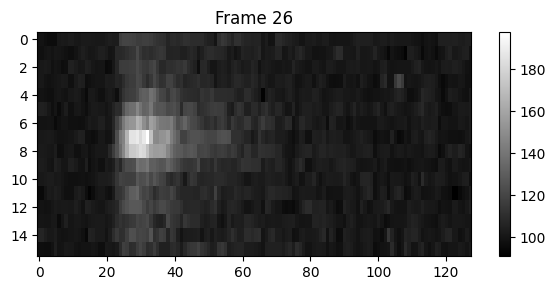

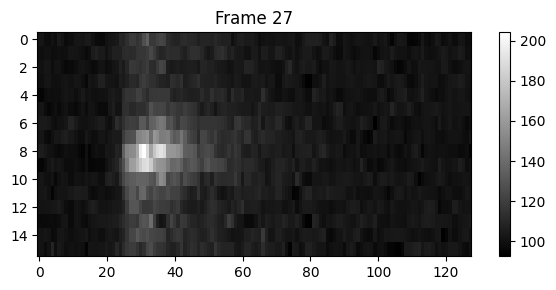

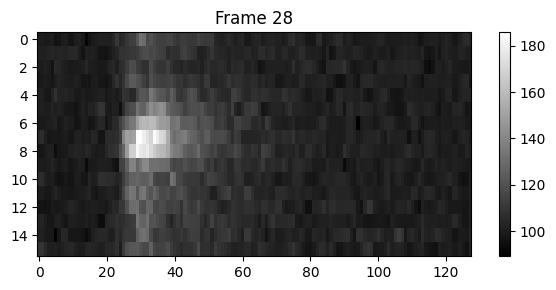

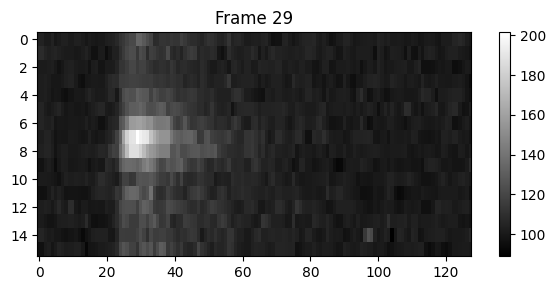

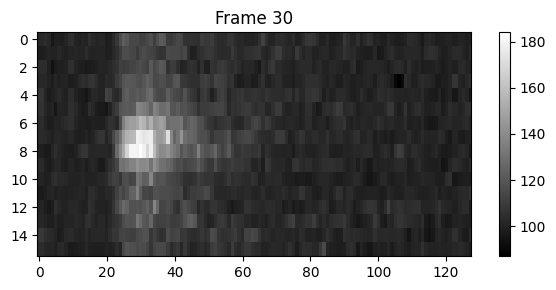

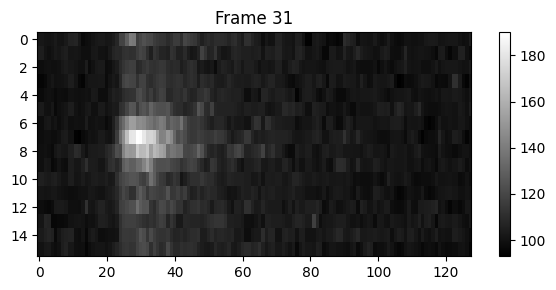

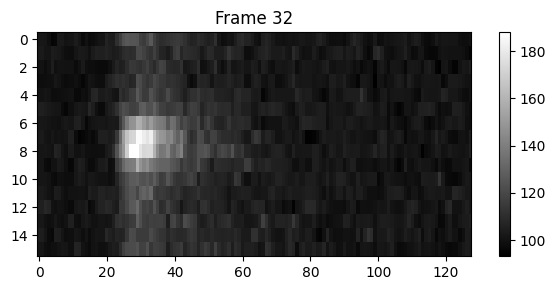

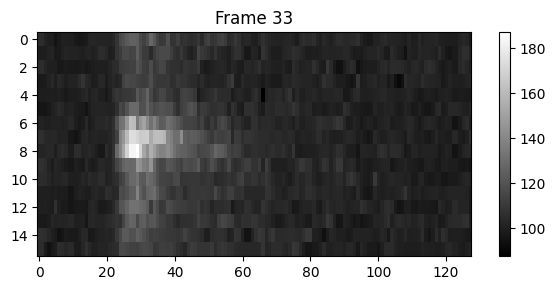

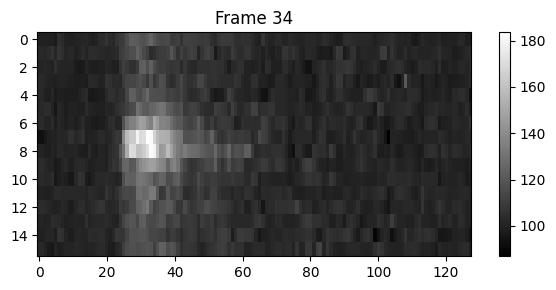

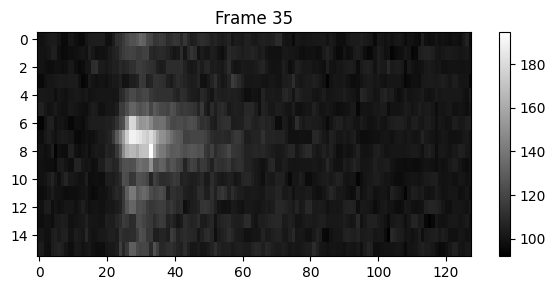

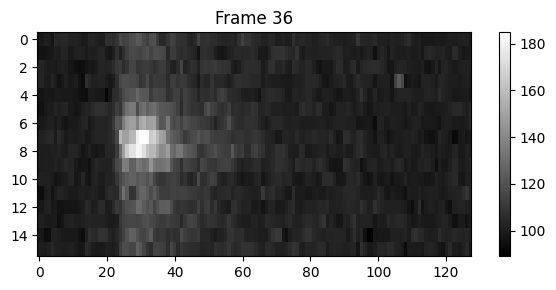

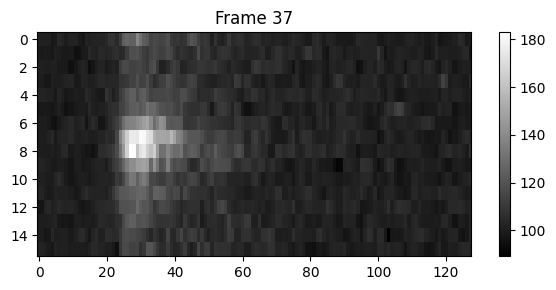

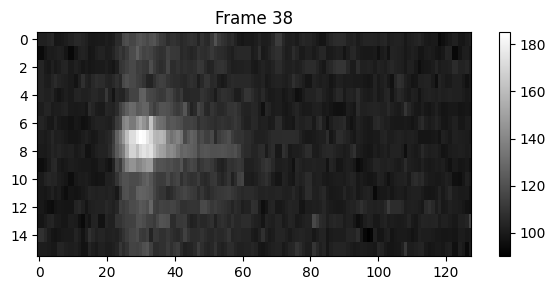

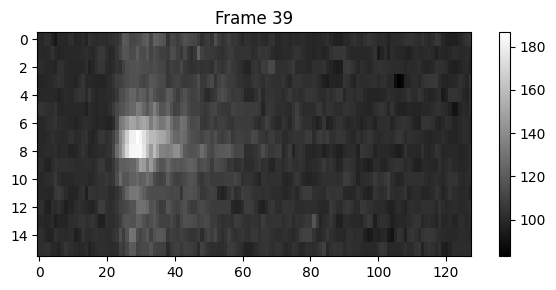

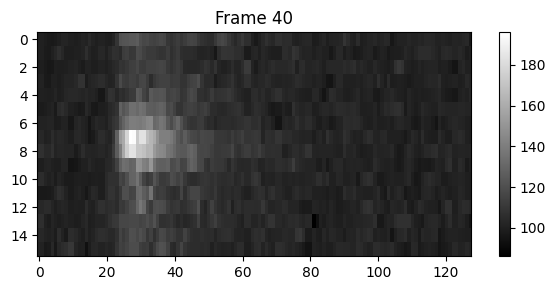

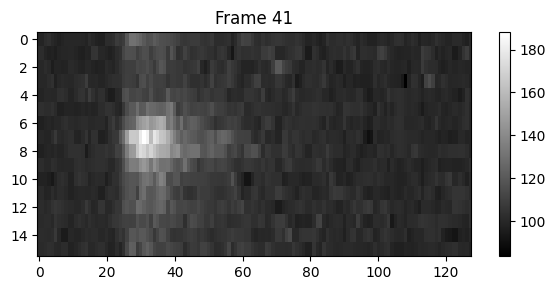

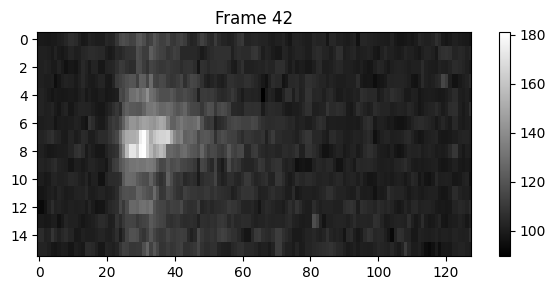

In [40]:
# %%
plt.gray()
max_show = min(1000, final_bbimg.shape[2])
for n in range(max_show):
    plt.figure(figsize=(6,3))
    plt.imshow(final_bbimg[:, :, n], aspect='auto')
    plt.title(f"Frame {n+1}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    # To slow down like MATLAB's pause(0.1), uncomment:
    # plt.pause(0.1)
